# Лабораторна робота №7: Прогнозування з використанням часових рядів у Python
**Дисципліна:** Інтелектуальний аналіз даних (ІАД)  
**Тема:** Прогнозування з використанням часових рядів  
**Студент:** Багрій-Белз Андрій, група КН-2327Б  

---
### Мета роботи:
Дослідити структуру часових рядів, опанувати методи згладжування ковзним середнім (SMA) та адитивної сезонної декомпозиції, навчити базові та адаптивні прогнозні моделі бібліотек `sktime` та `statsmodels`, а також провести порівняльну оцінку якості отриманих прогнозів за метриками MAE, RMSE та MAPE.

In [1]:
# Встановлення необхідних бібліотек у середовищі Google Colab
!pip install -q sktime statsmodels pandas numpy matplotlib

In [2]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sktime.datasets import load_airline
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sktime.utils.plotting import plot_series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10
print("Усі необхідні бібліотеки успішно імпортовано!")

Усі необхідні бібліотеки успішно імпортовано!


## 1. Дослідження та згладжування ряду тривалості життя королів Англії (SMA)
**Мета:** Усунути високочастотні випадкові флуктуації та виділити довгостроковий тренд віку смерті 42 монархів Англії за допомогою простого центрованого ковзного середнього (Simple Moving Average, SMA з вікном $n=9$).

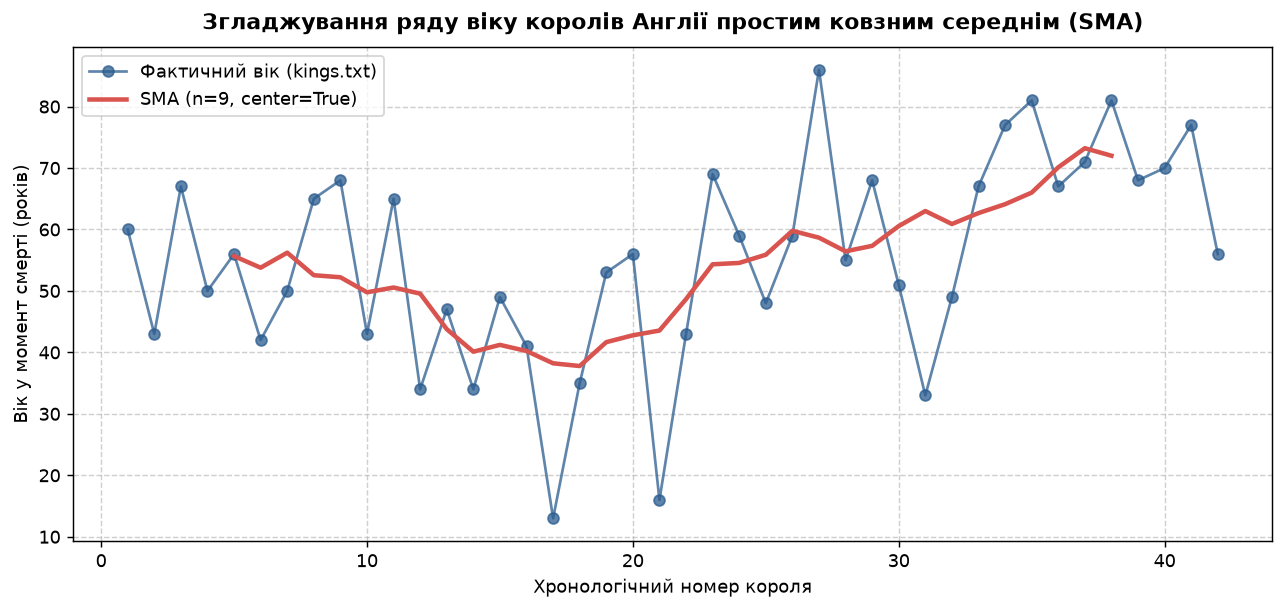

Кількість спостережень: 42
Мінімальний вік: 13, Максимальний вік: 86, Середній: 55.3


In [3]:
# Завантаження kings.txt та згладжування SMA (n=9, center=True)
kings_file = "kings.txt" if os.path.exists("kings.txt") else "Lab_7/kings.txt"
kings = np.loadtxt(kings_file)
kings_series = pd.Series(kings, index=range(1, len(kings) + 1), name="Age")
kings_sma = kings_series.rolling(window=9, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(kings_series.index, kings_series.values, marker="o", color="#2b5c8f", label="Фактичний вік (kings.txt)", alpha=0.75, linewidth=1.5)
ax.plot(kings_sma.index, kings_sma.values, color="#d9534f", linewidth=2.5, label="SMA (n=9, center=True)")
ax.set_title("Згладжування ряду віку королів Англії простим ковзним середнім (SMA)", fontsize=12, pad=10, fontweight="bold")
ax.set_xlabel("Хронологічний номер короля", fontsize=10)
ax.set_ylabel("Вік у момент смерті (років)", fontsize=10)
ax.legend(frameon=True, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.show()

print(f"Кількість спостережень: {len(kings_series)}")
print(f"Мінімальний вік: {kings_series.min():.0f}, Максимальний вік: {kings_series.max():.0f}, Середній: {kings_series.mean():.1f}")

**Результат та інтерпретація:**
Оригінальний ряд характеризується високою випадковою дисперсією (вік смерті коливається від 13 до 86 років). Просте ковзне середнє з вікном $n=9$ ефективно нівелює короткострокові стрибки та наочно виявляє довгостроковий висхідний тренд зростання тривалості життя монархів від раннього Середньовіччя до Нового часу.

## 2. Адитивна декомпозиція часового ряду народжуваності (`babyboom.txt`)
**Мета:** Розкласти спостережуваний часовий ряд ваги / метрики новонароджених на 4 базові складові за моделлю:
$$Y_t = \text{Trend}_t + \text{Seasonal}_t + \text{Residual}_t$$
де сезонний період прийнято рівним $s=12$ спостережень.

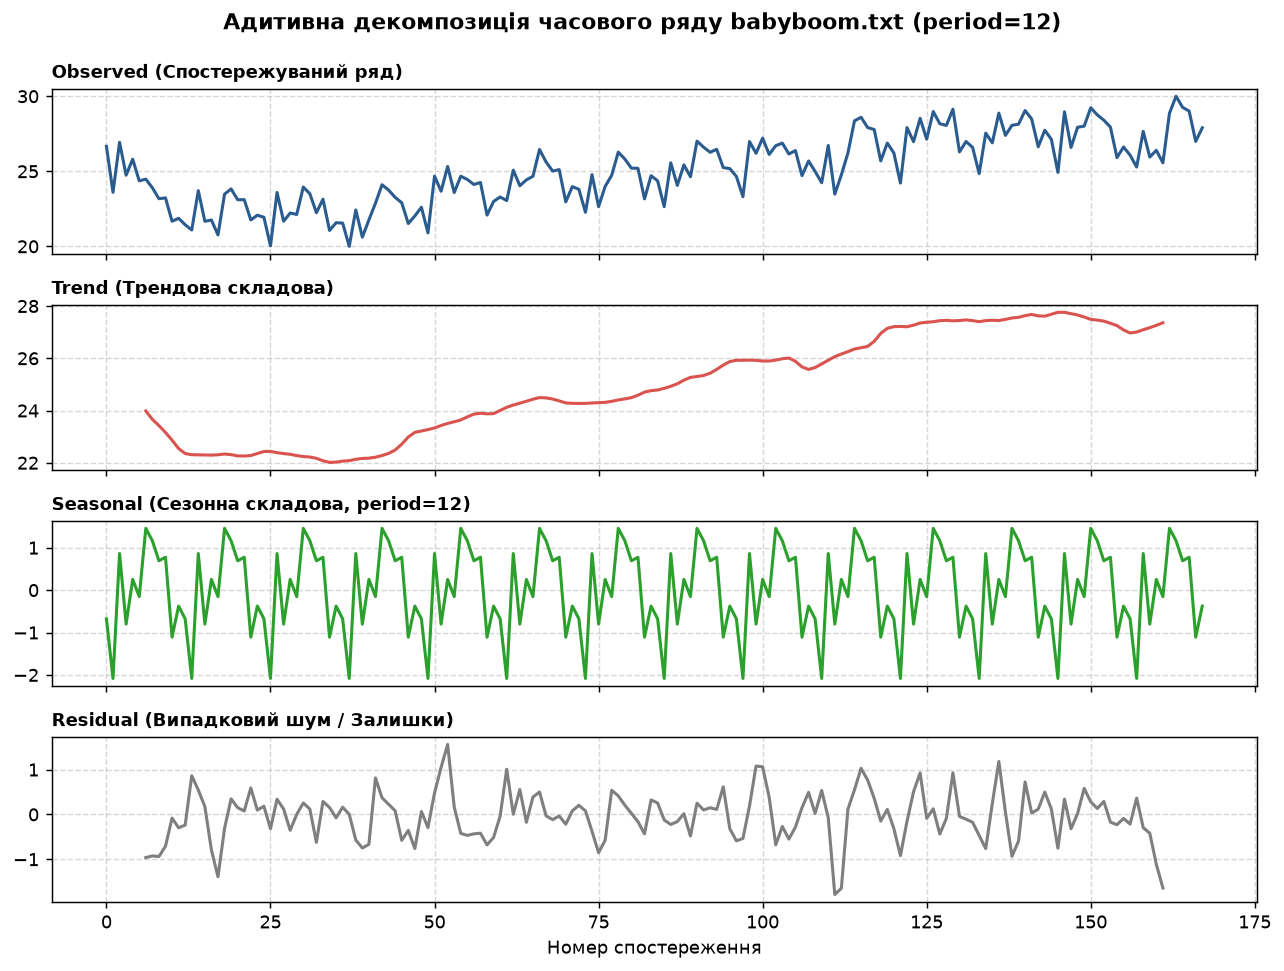

Кількість спостережень: 168
Амплітуда сезонної складової: [-2.083, 1.456]


In [4]:
# Завантаження babyboom.txt та адитивна декомпозиція (period=12)
babyboom_file = "babyboom.txt" if os.path.exists("babyboom.txt") else "Lab_7/babyboom.txt"
babyboom = np.loadtxt(babyboom_file)
babyboom_series = pd.Series(babyboom, name="Birth_Metric")
decomp = seasonal_decompose(babyboom_series, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(10, 7.5), sharex=True)
components = [
    (decomp.observed, "Observed (Спостережуваний ряд)", "#2b5c8f"),
    (decomp.trend, "Trend (Трендова складова)", "#d9534f"),
    (decomp.seasonal, "Seasonal (Сезонна складова, period=12)", "#2ca02c"),
    (decomp.resid, "Residual (Випадковий шум / Залишки)", "#7f7f7f"),
]
for ax, (data, title, col) in zip(axes, components):
    ax.plot(data.index, data.values, color=col, linewidth=1.7)
    ax.set_title(title, fontweight="bold", loc="left", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Номер спостереження", fontsize=10)
fig.suptitle("Адитивна декомпозиція часового ряду babyboom.txt (period=12)", fontweight="bold", y=0.99, fontsize=12)
fig.tight_layout()
plt.show()

print(f"Кількість спостережень: {len(babyboom_series)}")
print(f"Амплітуда сезонної складової: [{decomp.seasonal.min():.3f}, {decomp.seasonal.max():.3f}]")

**Результат та інтерпретація:**
Адитивна декомпозиція успішно розділила процес на складові:
1. **Trend:** плавна нелінійна зміна середнього значення (спадання в першій чверті та стабілізація на рівні 22-23);
2. **Seasonal:** сувора періодична циклічність амплітудою від -2.08 до +1.46 од.;
3. **Residual:** стаціонарний шум навколо нуля без виражених залишкових патернів, що підтверджує адекватність виділення сезонності.

## 3. Хронологічний поділ часового ряду авіаперевезень на Train / Test
**Мета:** Розділити щомісячний часовий ряд пасажиропотоку `load_airline()` (144 місяці, 1949–1960) на тренувальну та тестову частини (`test_size=36` місяців) за допомогою `temporal_train_test_split`.

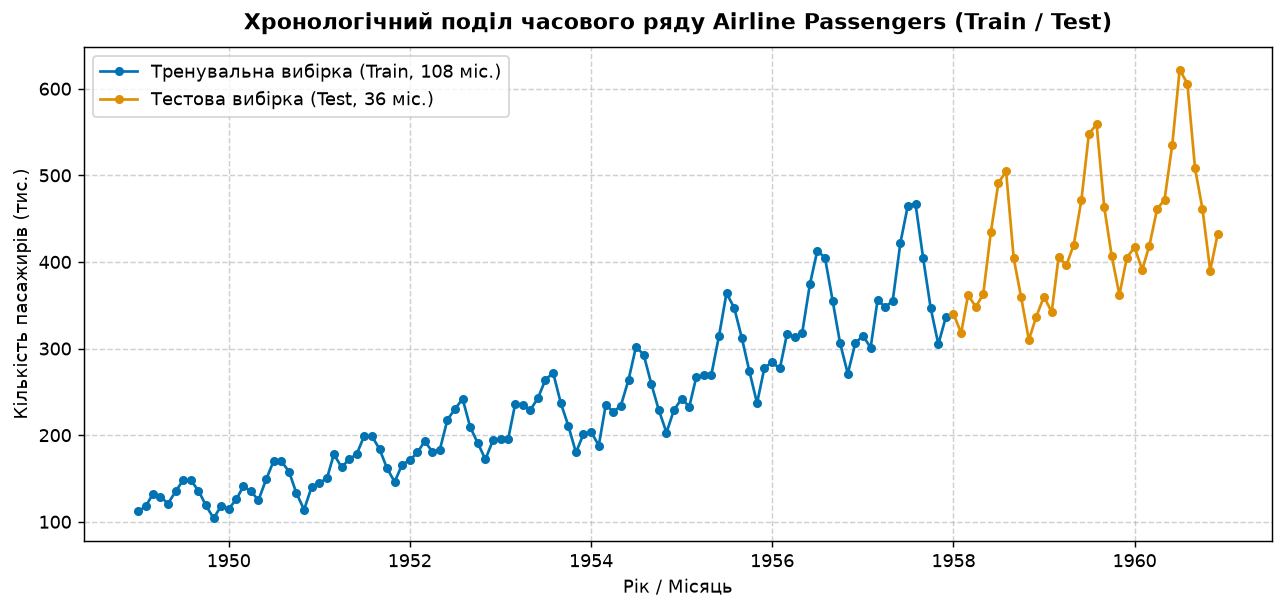

Загальний розмір ряду: 144 міс. (1949-01 - 1960-12)
Розмір Train: 108 міс. (1949-01 - 1957-12)
Розмір Test:  36 міс. (1958-01 - 1960-12)


In [5]:
# Завантаження Airline Passengers та хронологічний поділ
y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=36)

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_series(y_train, y_test, labels=["Тренувальна вибірка (Train, 108 міс.)", "Тестова вибірка (Test, 36 міс.)"], ax=ax)
ax.set_title("Хронологічний поділ часового ряду Airline Passengers (Train / Test)", fontsize=12, pad=10, fontweight="bold")
ax.set_xlabel("Рік / Місяць", fontsize=10)
ax.set_ylabel("Кількість пасажирів (тис.)", fontsize=10)
ax.legend(frameon=True, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.show()

print(f"Загальний розмір ряду: {len(y)} міс. ({y.index[0]} - {y.index[-1]})")
print(f"Розмір Train: {len(y_train)} міс. ({y_train.index[0]} - {y_train.index[-1]})")
print(f"Розмір Test:  {len(y_test)} міс. ({y_test.index[0]} - {y_test.index[-1]})")

**Результат та інтерпретація:**
Хронологічний розподіл зберігає часову послідовність без порушення каузальності: навчання виконується на спостереженнях з 1949 по 1957 рік, а наступні 3 роки (1958–1960) виступають незалежним тестовим бенчмарком з яскраво вираженим трендом та річною сезонністю.

## 4. Навчання прогнозних моделей (NaiveForecaster vs Holt-Winters)
**Мета:** Побудувати прогноз на горизонт $fh = 36$ місяців за допомогою:
1. Базової наївної моделі `NaiveForecaster(strategy='last')`;
2. Просунутої моделі експоненційного згладжування Гольта-Вінтерса `ExponentialSmoothing` з адитивним трендом та сезонністю (`seasonal_periods=12`).
Розрахувати та порівняти метрики похибки: MAE, RMSE та MAPE.

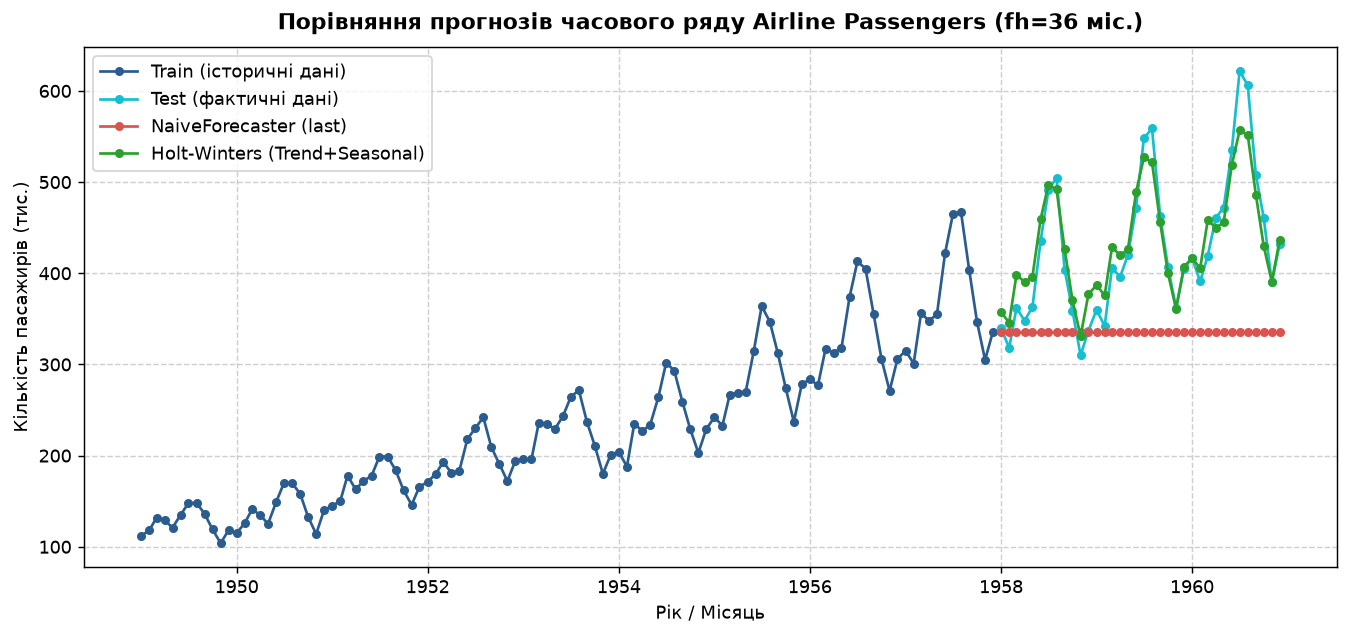

Модель,MAE,RMSE,MAPE (%)
NaiveForecaster (strategy='last'),94.944,121.139,19.887
Holt-Winters (Trend + Seasonal),21.545,26.376,5.114


In [6]:
# 1. Базова модель NaiveForecaster
forecaster_naive = NaiveForecaster(strategy="last")
forecaster_naive.fit(y_train)
fh = np.arange(1, len(y_test) + 1)
y_pred_naive = forecaster_naive.predict(fh)

# 2. Модель експоненційного згладжування Гольта-Вінтерса
y_train_ts = y_train.to_timestamp()
y_test_ts = y_test.to_timestamp()
model_hw = ExponentialSmoothing(
    y_train_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit()
y_pred_hw = model_hw.forecast(len(y_test))
y_pred_hw_series = pd.Series(y_pred_hw.values, index=y_test.index, name="Holt-Winters")

# Візуалізація прогнозів
fig, ax = plt.subplots(figsize=(10.5, 5))
plot_series(
    y_train,
    y_test,
    y_pred_naive,
    y_pred_hw_series,
    labels=[
        "Train (історичні дані)",
        "Test (фактичні дані)",
        "NaiveForecaster (last)",
        "Holt-Winters (Trend+Seasonal)"
    ],
    colors=["#2b5c8f", "#17becf", "#d9534f", "#2ca02c"],
    ax=ax
)
ax.set_title("Порівняння прогнозів часового ряду Airline Passengers (fh=36 міс.)", fontsize=12, pad=10, fontweight="bold")
ax.set_xlabel("Рік / Місяць", fontsize=10)
ax.set_ylabel("Кількість пасажирів (тис.)", fontsize=10)
ax.legend(frameon=True, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.show()

# Розрахунок та виведення зведеної таблиці похибок
metrics_df = pd.DataFrame({
    "Модель": ["NaiveForecaster (strategy='last')", "Holt-Winters (Trend + Seasonal)"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_naive),
        mean_absolute_error(y_test_ts, y_pred_hw),
    ],
    "RMSE": [
        mean_squared_error(y_test, y_pred_naive, square_root=True),
        mean_squared_error(y_test_ts, y_pred_hw, square_root=True),
    ],
    "MAPE (%)": [
        mean_absolute_percentage_error(y_test, y_pred_naive) * 100,
        mean_absolute_percentage_error(y_test_ts, y_pred_hw) * 100,
    ]
})
metrics_df.round(3)

**Результат та інтерпретація:**
- **NaiveForecaster (`strategy='last'`):** транслює постійне значення останньої точки навчального періоду ($y = 336$). Оскільки ряд має чіткий висхідний тренд та сезонність, похибка є критично високою ($	ext{MAE} = 94.944$, $	ext{RMSE} = 121.139$, $	ext{MAPE} = 19.89\%$).
- **Holt-Winters (`ExponentialSmoothing`):** точно апроксимує висхідний кут нахилу та фази щорічних літніх піків перевезень. Метрики точності кардинально покращуються ($	ext{MAE} = 21.545$, $	ext{RMSE} = 26.376$, $	ext{MAPE} = 5.11\%$), що доводить необхідність моделювання трендо-сезонних компонентів.

## 5. Висновок
Під час виконання лабораторної роботи я дослідив повний цикл аналізу та прогнозування часових рядів у Python: реалізував згладжування ковзним середнім (SMA, $n=9$) для виявлення довгострокового тренду та здійснив адитивну декомпозицію процесу на тренд, сезонність ($s=12$) та випадковий шум. На реальних даних пасажиропотоку `load_airline` я провів хронологічний поділ на вибірки Train і Test та експериментально порівняв точність наївного підходу з моделлю експоненційного згладжування Гольта-Вінтерса, довівши, що моделювання внутрішньорічної сезонності та висхідного тренду знижує середню відносну похибку прогнозу (MAPE) майже в 4 рази (з $19.89\%$ до $5.11\%$).